In [32]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [10]:
# Load data
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("sentimentdataset.csv")

Saving sentimentdataset.csv to sentimentdataset (1).csv


In [3]:
df.head()

,Text,Sentiment,Platform,Likes,Retweets,Country,Cleaned_Text
0,Enjoying a beautiful day at the park! ...,Positive,Twitter,30,15,USA,enjoying a beautiful day at the park ...
1,Traffic was terrible this morning. ...,Negative,Twitter,10,5,Canada,traffic was terrible this morning ...
2,Just finished an amazing workout! 💪 ...,Positive,Instagram,40,20,USA,just finished an amazing workout
3,Excited about the upcoming weekend getaway! ...,Positive,Facebook,15,8,UK,excited about the upcoming weekend getaway ...
4,Trying out a new recipe for dinner tonight. ...,Neutral,Instagram,25,12,Australia,trying out a new recipe for dinner tonight ...


In [4]:
df.shape

(732, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Text          732 non-null    object
 1   Sentiment     732 non-null    object
 2   Platform      732 non-null    object
 3   Likes         732 non-null    int64 
 4   Retweets      732 non-null    int64 
 5   Country       732 non-null    object
 6   Cleaned_Text  732 non-null    object
dtypes: int64(2), object(5)
memory usage: 40.2+ KB


In [6]:
df.describe()

,Likes,Retweets
count,732.000000,732.000000
mean,42.901639,21.508197
std,14.089848,7.061286
min,10.000000,5.000000
25%,34.750000,17.750000
50%,43.000000,22.000000
75%,50.000000,25.000000
max,80.000000,40.000000


In [7]:
df.isnull().sum()

,0
Text,0
Sentiment,0
Platform,0
Likes,0
Retweets,0
Country,0
Cleaned_Text,0


In [21]:
# Fill missing values if any
df.fillna('', inplace=True)

# Check sentiment distribution
print(df['Sentiment'].value_counts())


Sentiment
Positive               44
Joy                    42
Excitement             32
Happy                  14
Neutral                14
                       ..
Vibrancy                1
Culinary Adventure      1
Mesmerizing             1
Thrilling Journey       1
Winter Magic            1
Name: count, Length: 279, dtype: int64


In [15]:
# Drop unnecessary columns for analysis
df = df[['Text', 'Sentiment', 'Platform', 'Likes', 'Retweets', 'Country']]

# Convert text to lowercase & remove special characters
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

df['Cleaned_Text'] = df['Text'].apply(clean_text)

In [16]:
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

df['Sentiment_Score'] = df['Cleaned_Text'].apply(get_sentiment)

# Define sentiment category
df['Sentiment_Category'] = df['Sentiment_Score'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral'))

print(df[['Cleaned_Text', 'Sentiment_Category']].head())

                                        Cleaned_Text Sentiment_Category
0   enjoying a beautiful day at the park         ...           Positive
1   traffic was terrible this morning            ...           Negative
2   just finished an amazing workout                           Positive
3   excited about the upcoming weekend getaway   ...           Positive
4   trying out a new recipe for dinner tonight   ...           Positive


In [40]:
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

df['Sentiment_Score'] = df['Cleaned_Text'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['Sentiment_Category'] = df['Sentiment_Score'].apply(lambda x: 'Positive' if x > 0.2 else ('Negative' if x < -0.2 else 'Neutral'))

# Sentiment Distribution
df['Sentiment_Category'].value_counts()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,count
Sentiment_Category,
Positive,437
Negative,171
Neutral,124


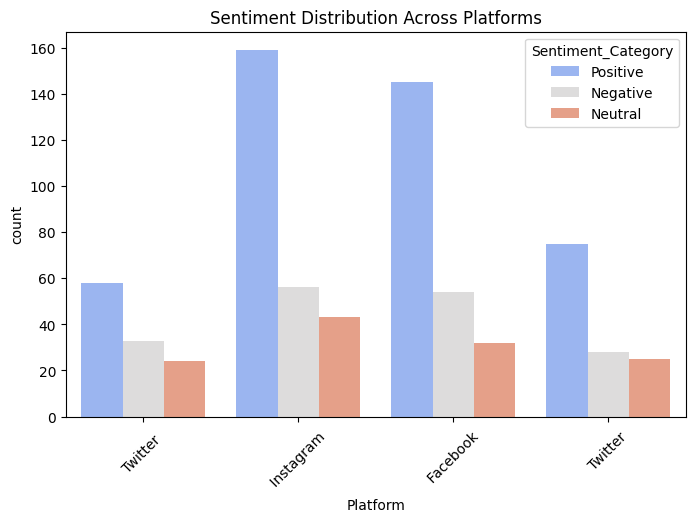

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Platform', hue='Sentiment_Category', palette='coolwarm')
plt.title('Sentiment Distribution Across Platforms')
plt.xticks(rotation=45)
plt.show()

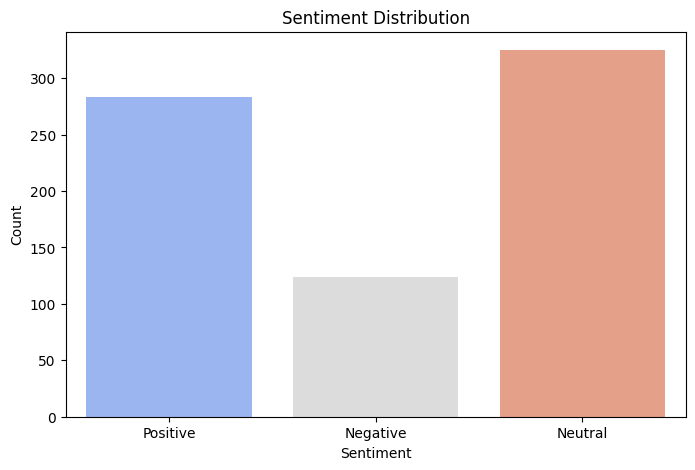

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Sentiment_Category', palette='coolwarm')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

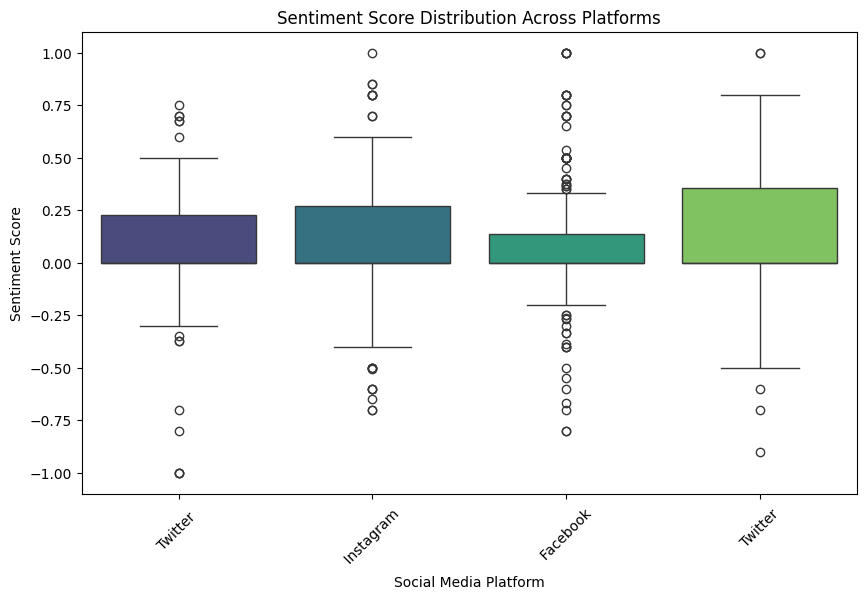

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Platform', y='Sentiment_Score', palette='viridis')
plt.title('Sentiment Score Distribution Across Platforms')
plt.xlabel('Social Media Platform')
plt.ylabel('Sentiment Score')
plt.xticks(rotation=45)
plt.show()

In [42]:
sia = SentimentIntensityAnalyzer()

# Extract aspect-wise sentiment
def get_sentiment(text):
    blob = TextBlob(text)
    sentiment_score = sia.polarity_scores(text)['compound']
    return sentiment_score

df['Sentiment_Score'] = df['Cleaned_Text'].apply(get_sentiment)
df['Sentiment_Category'] = df['Sentiment_Score'].apply(lambda x: 'Positive' if x > 0.2 else ('Negative' if x < -0.2 else 'Neutral'))
df.head()

,Text,Sentiment,Platform,Likes,Retweets,Country,Cleaned_Text,Sentiment_Score,Sentiment_Category,Polarity_Score,Predicted_Sentiment
0,Enjoying a beautiful day at the park! ...,Positive,Twitter,30,15,USA,enjoying a beautiful day at the park ...,0.8074,Positive,0.750000,Positive
1,Traffic was terrible this morning. ...,Negative,Twitter,10,5,Canada,traffic was terrible this morning ...,-0.4767,Negative,-1.000000,Negative
2,Just finished an amazing workout! 💪 ...,Positive,Instagram,40,20,USA,just finished an amazing workout,0.5859,Positive,0.750000,Positive
3,Excited about the upcoming weekend getaway! ...,Positive,Facebook,15,8,UK,excited about the upcoming weekend getaway ...,0.3400,Positive,0.468750,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral,Instagram,25,12,Australia,trying out a new recipe for dinner tonight ...,0.0000,Neutral,0.136364,Positive


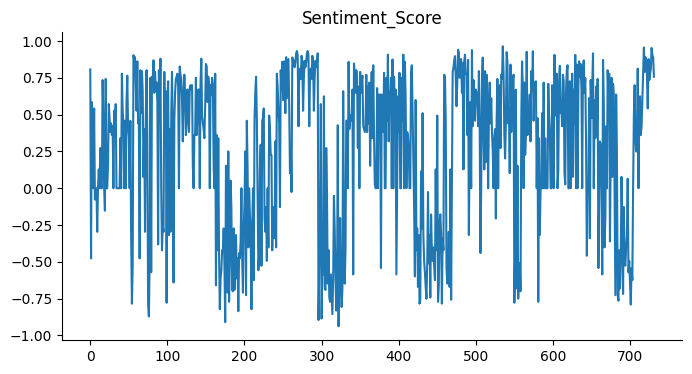

In [49]:
# Sentiment_Score
df['Sentiment_Score'].plot(kind='line', figsize=(8, 4), title='Sentiment_Score')
plt.gca().spines[['top', 'right']].set_visible(False)

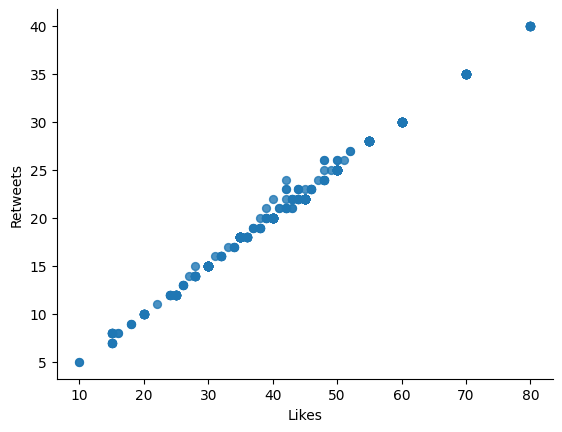

In [50]:
# Likes vs Retweets
df.plot(kind='scatter', x='Likes', y='Retweets', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

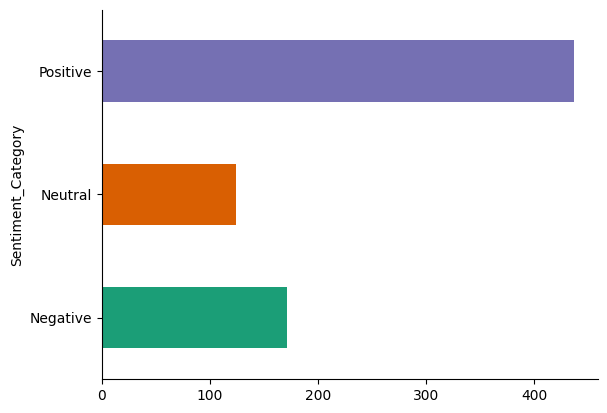

In [51]:
# Sentiment_Category
df.groupby('Sentiment_Category').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)